# Task 2 — Credit Card Fraud Detection

**CodSoft ML Internship**

Flag fraudulent card transactions from the transaction record and cardholder profile.

- **Dataset:** [Fraud Detection](https://www.kaggle.com/datasets/kartik2112/fraud-detection) (Sparkov simulator) — **1.85 million transactions**, 983 cards, Jan 2019 to Dec 2020.
- **Approach:** engineer features from raw columns → compare three classifiers → RandomForest.
- **Headline metric:** **PR-AUC** (average precision). Not accuracy, and — importantly — **not ROC-AUC either**.

Fraud is **0.39%** of the test set. A model that says "never fraud" is **99.61% accurate**. That much
is familiar from the other tasks in this repo. What is new here is that the metric which rescued us
there — ROC-AUC — *also* breaks at this level of imbalance, and §6 shows it picking the wrong model.

In [1]:
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, average_precision_score,
                             classification_report, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score, recall_score,
                             roc_auc_score, roc_curve)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 220)
DATA = "data/"

---
## 1. Load the data

The dataset ships **two files**, and how they were split matters enormously.

In [2]:
train_raw = pd.read_csv(DATA + "fraudTrain.csv", index_col=0)
test_raw = pd.read_csv(DATA + "fraudTest.csv", index_col=0)

print(f"train : {train_raw.shape[0]:,} transactions")
print(f"test  : {test_raw.shape[0]:,} transactions")
print(f"missing values : {train_raw.isna().sum().sum() + test_raw.isna().sum().sum()}")
print(f"duplicate rows : {train_raw.duplicated().sum()}")
print(f"\ncolumns ({train_raw.shape[1]}): {list(train_raw.columns)}")
train_raw.head(3)

train : 1,296,675 transactions
test  : 555,719 transactions


missing values : 0


duplicate rows : 0

columns (22): ['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0


### 1.1 The split is temporal, not random — and that is the right call

Check the date ranges before doing anything else.

In [3]:
for name, df in [("train", train_raw), ("test", test_raw)]:
    t = pd.to_datetime(df["trans_date_trans_time"])
    print(f"  {name:5s}: {t.min()}  ->  {t.max()}")

shared_cards = len(set(train_raw["cc_num"]) & set(test_raw["cc_num"]))
print(f"\ncards: {train_raw['cc_num'].nunique()} in train, "
      f"{test_raw['cc_num'].nunique()} in test, {shared_cards} in both")

  train: 2019-01-01 00:00:18  ->  2020-06-21 12:13:37


  test : 2020-06-21 12:14:25  ->  2020-12-31 23:59:34

cards: 983 in train, 924 in test, 908 in both


The test set is strictly **after** the training set — the training period ends and the test period
begins the same minute. The same cards appear in both.

This is exactly how a fraud model should be evaluated. In production you train on the past and score
transactions that have not happened yet, so a **random** split would be dishonest: it would let the
model learn from June 2020 to predict January 2020, using information that would not exist at
decision time. A temporal split measures the thing we actually care about — does the model still work
next month?

It also means the two splits are allowed to differ, and they do: the fraud rate is not identical
across the two periods. We report that rather than assuming it away.

### 1.2 Drop the identifier columns

| Column | Why it goes |
|---|---|
| `trans_num` | A unique hash per transaction. 1.3M distinct values, pure noise. |
| `cc_num` | The card number. See the note below — it is tempting and wrong. |
| `first`, `last`, `street` | Names and addresses. Identifiers, and no bank should model on them. |
| `city`, `state`, `zip`, `job` | High-cardinality location/occupation labels that stand in for *which cardholder this is*, not for fraud risk. |
| `merchant` | 693 merchants. Excluded for the same reason — see §7.1 where we check whether this was the right call. |
| `unix_time` | The timestamp again, as an integer. Feeding a raw clock to a tree invites it to memorise the training period, which cannot generalise forward. |
| `lat`, `long`, `merch_lat`, `merch_long` | Kept only long enough to compute distance (§3), then dropped. |

In [4]:
print("cardinality of the columns we are dropping:")
for col in ["trans_num", "cc_num", "merchant", "job", "city", "state"]:
    print(f"  {col:11s} {train_raw[col].nunique():>9,} distinct values")

cardinality of the columns we are dropping:


  trans_num   1,296,675 distinct values
  cc_num            983 distinct values
  merchant          693 distinct values
  job               494 distinct values
  city              894 distinct values
  state              51 distinct values


---
## 2. How imbalanced is it?

  train:  7,506 fraud / 1,296,675 = 0.5789%   ('never fraud' accuracy: 99.4211%)
  test :  2,145 fraud /   555,719 = 0.3860%   ('never fraud' accuracy: 99.6140%)


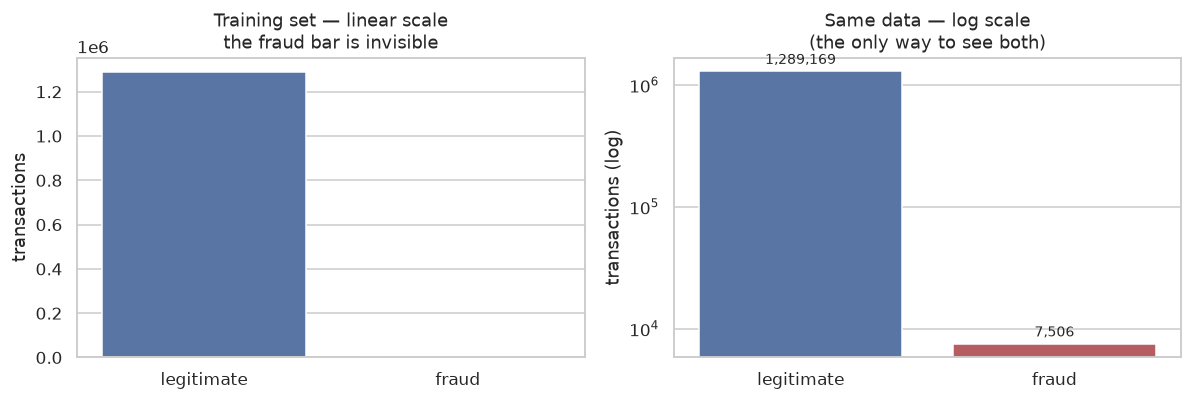

In [5]:
for name, df in [("train", train_raw), ("test", test_raw)]:
    rate = df["is_fraud"].mean()
    print(f"  {name:5s}: {int(df['is_fraud'].sum()):>6,} fraud / {len(df):>9,} "
          f"= {rate:.4%}   ('never fraud' accuracy: {1 - rate:.4%})")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
counts = train_raw["is_fraud"].value_counts().sort_index()
sns.barplot(x=["legitimate", "fraud"], y=counts.values, ax=axes[0],
            hue=["legitimate", "fraud"], palette=["#4c72b0", "#c44e52"], legend=False)
axes[0].set(title="Training set — linear scale\nthe fraud bar is invisible", ylabel="transactions", xlabel="")
sns.barplot(x=["legitimate", "fraud"], y=counts.values, ax=axes[1],
            hue=["legitimate", "fraud"], palette=["#4c72b0", "#c44e52"], legend=False)
axes[1].set_yscale("log")
axes[1].set(title="Same data — log scale\n(the only way to see both)", ylabel="transactions (log)", xlabel="")
for i, v in enumerate(counts.values):
    axes[1].text(i, v * 1.15, f"{v:,}", ha="center", fontsize=9)
fig.tight_layout()
fig.savefig("results/class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

**The left panel is the point.** At 0.58% positives the fraud bar is not small, it is *invisible* —
you have to switch to a log scale to see that the minority class exists at all.

Compare across this repo:

| Task | Positive rate | "Predict the majority" accuracy |
|---|---|---|
| 3 — churn | 20% | 79.6% |
| 4 — spam | 13% | 87.4% |
| **2 — fraud** | **0.39%** | **99.61%** |

A useless model here scores 99.61%. Accuracy is not merely misleading, it is actively absurd.

---
## 3. Feature engineering

The other three tasks in this repo use their columns as given. This one cannot: the useful signals
are **not columns**, they are things you have to derive.

| Derived feature | From | Reasoning |
|---|---|---|
| `hour`, `is_night` | `trans_date_trans_time` | Card-not-present fraud is automated and runs at night. |
| `dayofweek` | `trans_date_trans_time` | Weekday/weekend spending patterns differ. |
| `age` | `dob` and the transaction date | Not stored — it is a *difference* between two dates. |
| `distance_km` | `lat`/`long` vs `merch_lat`/`merch_long` | Haversine distance from home to merchant. A purchase far from home is a classic flag. |

Whether each of these actually *works* is an empirical question, and one of them will not.

In [6]:
def haversine_km(lat1, lon1, lat2, lon2):
    '''Great-circle distance in km between two lat/long points.'''
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi, dlambda = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


def engineer(df):
    '''Turn the raw transaction record into the model's feature table.'''
    ts = pd.to_datetime(df["trans_date_trans_time"])
    return pd.DataFrame({
        "amt": df["amt"],
        "category": df["category"],
        "hour": ts.dt.hour,
        "is_night": ts.dt.hour.isin([22, 23, 0, 1, 2, 3]).astype(int),
        "dayofweek": ts.dt.dayofweek,
        "age": (ts - pd.to_datetime(df["dob"])).dt.days / 365.25,
        "gender": df["gender"],
        "city_pop": df["city_pop"],
        "distance_km": haversine_km(df["lat"], df["long"],
                                    df["merch_lat"], df["merch_long"]),
    })


X_train, y_train = engineer(train_raw), train_raw["is_fraud"]
X_test, y_test = engineer(test_raw), test_raw["is_fraud"]

print(f"feature table: {X_train.shape[1]} features")
print(f"train {X_train.shape}   test {X_test.shape}")
X_train.head(3)

feature table: 9 features
train (1296675, 9)   test (555719, 9)


,amt,category,hour,is_night,dayofweek,age,gender,city_pop,distance_km
0,4.97,misc_net,0,1,1,30.814511,F,3495,78.597568
1,107.23,grocery_pos,0,1,1,40.531143,F,149,30.212176
2,220.11,entertainment,0,1,1,56.950034,M,4154,108.206083


---
## 4. Exploratory analysis — does any of it carry signal?

### 4.1 Transaction amount

                count    mean     50%     75%       max
legitimate  1289169.0   67.67   47.28   82.54  28948.90
fraud          7506.0  531.32  396.50  900.88   1376.04


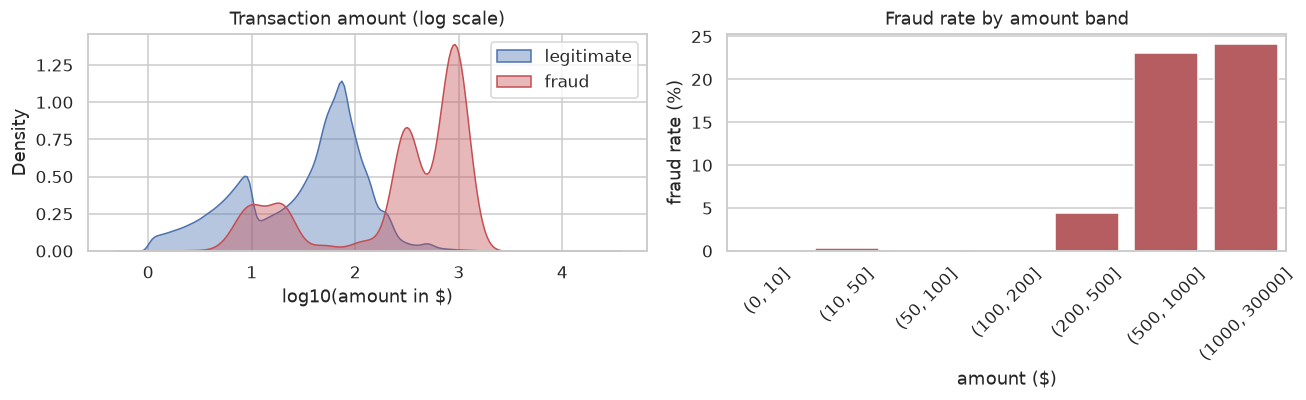

In [7]:
amt_stats = train_raw.groupby("is_fraud")["amt"].describe()[["count", "mean", "50%", "75%", "max"]]
amt_stats.index = ["legitimate", "fraud"]
print(amt_stats.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for label, colour in [(0, "#4c72b0"), (1, "#c44e52")]:
    sns.kdeplot(np.log10(train_raw.loc[train_raw["is_fraud"] == label, "amt"]),
                ax=axes[0], fill=True, alpha=0.4, color=colour,
                label=["legitimate", "fraud"][label])
axes[0].set(title="Transaction amount (log scale)", xlabel="log10(amount in $)")
axes[0].legend()

bins = [0, 10, 50, 100, 200, 500, 1000, 30000]
tmp = train_raw.assign(band=pd.cut(train_raw["amt"], bins))
rate = tmp.groupby("band", observed=True)["is_fraud"].mean() * 100
sns.barplot(x=[str(b) for b in rate.index], y=rate.values, ax=axes[1], color="#c44e52")
axes[1].set(title="Fraud rate by amount band", ylabel="fraud rate (%)", xlabel="amount ($)")
axes[1].tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig("results/amount_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

Fraudulent transactions are far larger — a median around \$400 against roughly \$47 for legitimate
ones. The distributions are clearly separated but they overlap heavily in the middle, so amount alone
will not do the job.

### 4.2 Hour of day — the strongest signal in the dataset

22:00-03:59 : 2.0867% fraud
04:00-21:59 : 0.1153% fraud
ratio       : 18.1x


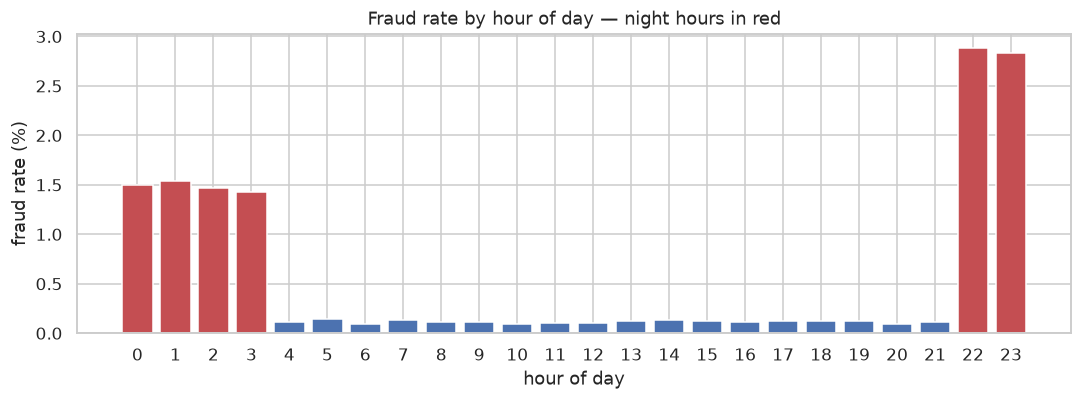


Pearson correlation between raw `hour` and `is_fraud`: +0.0138


In [8]:
hourly = train_raw.copy()
hourly["hour"] = pd.to_datetime(hourly["trans_date_trans_time"]).dt.hour
by_hour = hourly.groupby("hour")["is_fraud"].agg(["count", "mean"])

night_hours = [22, 23, 0, 1, 2, 3]
night = hourly[hourly["hour"].isin(night_hours)]["is_fraud"].mean()
day = hourly[~hourly["hour"].isin(night_hours)]["is_fraud"].mean()
print(f"22:00-03:59 : {night:.4%} fraud")
print(f"04:00-21:59 : {day:.4%} fraud")
print(f"ratio       : {night / day:.1f}x")

fig, ax = plt.subplots(figsize=(10, 3.8))
colours = ["#c44e52" if h in night_hours else "#4c72b0" for h in by_hour.index]
ax.bar(by_hour.index, by_hour["mean"] * 100, color=colours)
ax.set(title="Fraud rate by hour of day — night hours in red",
       xlabel="hour of day", ylabel="fraud rate (%)", xticks=range(0, 24))
fig.tight_layout()
fig.savefig("results/fraud_by_hour.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nPearson correlation between raw `hour` and `is_fraud`: "
      f"{hourly['hour'].corr(hourly['is_fraud']):+.4f}")

### This is the most instructive plot in the notebook

Fraud is **18 times** more likely between 22:00 and 04:00 than during the day. It is far and away the
strongest signal available.

Now look at the Pearson correlation with raw `hour`: about **+0.01**. Essentially zero.

**Why?** Because the risky window *wraps around midnight*. Hours 22, 23, 0, 1, 2, 3 are the dangerous
ones — but numerically that is the top of the range and the bottom of the range with everything safe
in between. Correlation measures a straight line, and this is a U with its ends glued together. Any
feature-selection routine that ranks by correlation would discard the best predictor in the dataset.

This is the same trap as Task 3's `NumOfProducts` (correlation 0.048 for the strongest feature there),
and it is why we hand `is_night` to the model explicitly rather than trusting `hour` to speak for
itself — and why linear models are going to struggle here.

### 4.3 Category, and why "large amount = fraud" is too simple

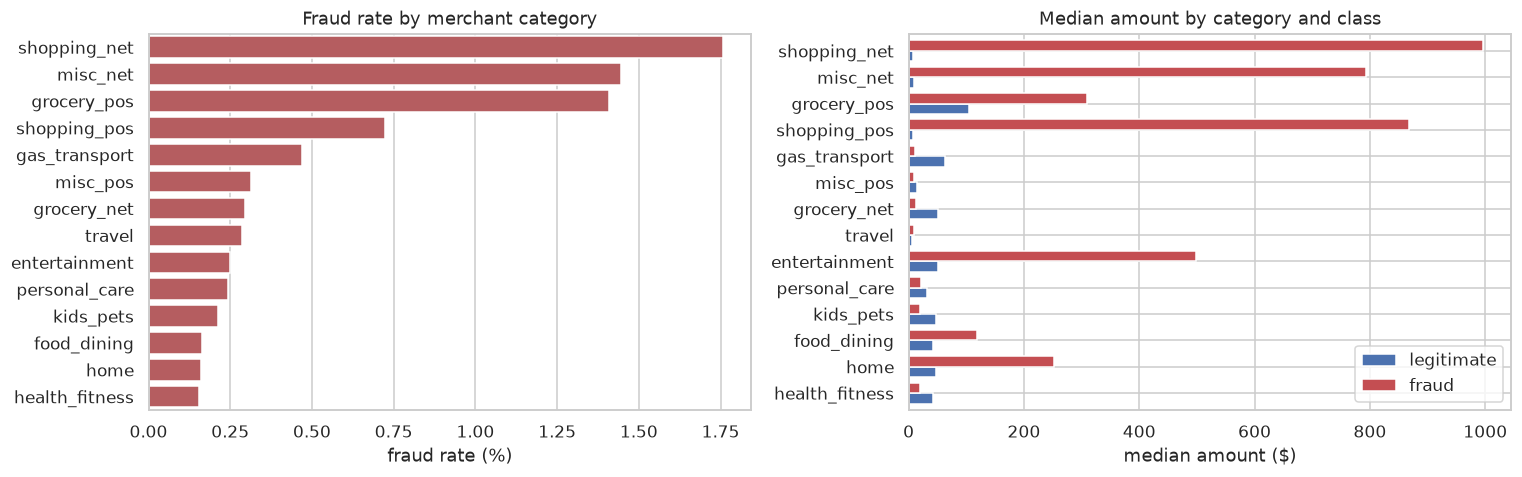

is_fraud        legitimate   fraud
category                          
health_fitness       42.94   19.80
home                 48.17  252.16
food_dining          41.93  119.42
kids_pets            47.24   19.52
personal_care        32.67   20.82
entertainment        50.55  498.86
travel                6.25    9.74
grocery_net          50.99   12.36
misc_pos             13.95    8.96
gas_transport        62.93   10.64
shopping_pos          7.71  867.76
grocery_pos         104.55  309.98
misc_net              9.68  792.33
shopping_net          8.30  995.57


In [9]:
cat_stats = (train_raw.groupby("category")
             .agg(transactions=("is_fraud", "size"), fraud_rate=("is_fraud", "mean"))
             .sort_values("fraud_rate", ascending=False))
cat_stats["fraud_rate"] *= 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(x=cat_stats["fraud_rate"], y=cat_stats.index, ax=axes[0], color="#c44e52")
axes[0].set(title="Fraud rate by merchant category", xlabel="fraud rate (%)", ylabel="")

medians = (train_raw.groupby(["category", "is_fraud"])["amt"].median()
           .unstack().rename(columns={0: "legitimate", 1: "fraud"}))
medians = medians.loc[cat_stats.index[::-1]]   # pandas barh draws bottom-up; match the left panel
medians.plot(kind="barh", ax=axes[1], color=["#4c72b0", "#c44e52"], width=0.8)
axes[1].set(title="Median amount by category and class", xlabel="median amount ($)", ylabel="")
axes[1].legend(title="")
fig.tight_layout()
fig.savefig("results/category_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(medians.round(2).to_string())

Two things here.

**Fraud rate varies about elevenfold across categories** — online shopping and in-person groceries at
the top, health and fitness at the bottom. Worth having.

**More importantly, the right-hand panel breaks the naive rule.** In `shopping_net` the median fraud
is roughly a hundred times the median legitimate purchase — a huge gap. But in `health_fitness` the
fraudulent transactions are *smaller* than the legitimate ones.

So "large amount ⇒ fraud" is **wrong as a global rule**. What matters is the amount *relative to what
is normal for that category*. A linear model has to pick one coefficient for `amt` and apply it
everywhere; a tree can split on category first and then apply a different amount threshold in each
branch. That is a concrete, measurable reason to expect trees to win here.

### 4.4 Age, and a feature that does not work

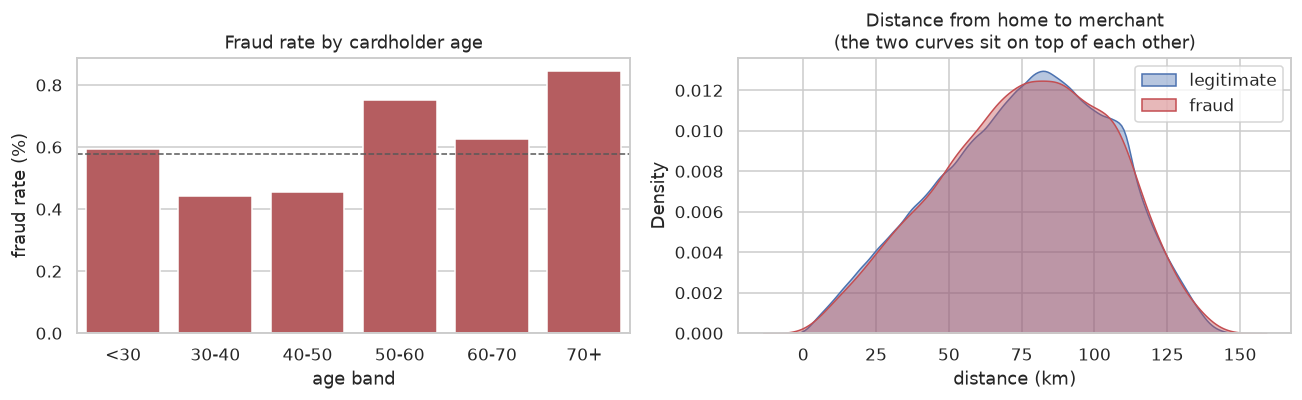

              count   mean    50%
is_fraud                         
0         1289169.0  76.11  78.23
1            7506.0  76.27  77.93


In [10]:
aged = train_raw.copy()
ts = pd.to_datetime(aged["trans_date_trans_time"])
aged["age"] = (ts - pd.to_datetime(aged["dob"])).dt.days / 365.25
aged["distance_km"] = haversine_km(aged["lat"], aged["long"],
                                   aged["merch_lat"], aged["merch_long"])
aged["age_band"] = pd.cut(aged["age"], [0, 30, 40, 50, 60, 70, 120],
                          labels=["<30", "30-40", "40-50", "50-60", "60-70", "70+"])

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
rate = aged.groupby("age_band", observed=True)["is_fraud"].mean() * 100
sns.barplot(x=rate.index.astype(str), y=rate.values, ax=axes[0], color="#c44e52")
axes[0].axhline(train_raw["is_fraud"].mean() * 100, ls="--", c="0.35", lw=1)
axes[0].set(title="Fraud rate by cardholder age", ylabel="fraud rate (%)", xlabel="age band")

for label, colour in [(0, "#4c72b0"), (1, "#c44e52")]:
    sns.kdeplot(aged.loc[aged["is_fraud"] == label, "distance_km"], ax=axes[1],
                fill=True, alpha=0.4, color=colour, label=["legitimate", "fraud"][label])
axes[1].set(title="Distance from home to merchant\n(the two curves sit on top of each other)",
            xlabel="distance (km)")
axes[1].legend()
fig.tight_layout()
fig.savefig("results/age_distance.png", dpi=150, bbox_inches="tight")
plt.show()

print(aged.groupby("is_fraud")["distance_km"].describe()[["count", "mean", "50%"]].round(2).to_string())

**Age carries a real if modest signal, and it is not monotonic.** The fraud rate bottoms out at
0.44% for 30–40 year olds, and climbs steadily with age from there to 0.85% for the over-70s. The
under-30s sit at 0.59% — above the middle-aged floor, but well below the oldest band. So it is not a
clean U: the dominant pattern is *risk rising with age after 50*, with a smaller bump at the young
end.

**Distance is a dead feature, and that is worth saying out loud.** The mean distance from home is
about 76 km for fraud and about 76 km for legitimate transactions. The distributions are
indistinguishable.

I engineered this feature expecting it to be one of the best — "purchase far from home" is textbook
fraud detection. It contributes nothing here, because the data is **simulated**: the generator draws
each merchant's location uniformly around the cardholder regardless of whether the transaction is
fraudulent, so the relationship that exists in real card data was never put into this dataset.

We keep it in the model (it costs nothing and §7 confirms it is harmless) and report it as a negative
result. A feature that failed is still a finding — quietly deleting it would hide the most important
caveat about this dataset.

---
## 5. Model comparison

Three classifiers on the temporal holdout — 555,719 transactions from the six months *after* the
training period:

- **LogisticRegression** — linear baseline, `class_weight="balanced"`.
- **RandomForest** — bagged trees, `class_weight="balanced_subsample"`.
- **HistGradientBoosting** — histogram-based boosting, built for datasets this size.

*(This cell fits three models on 1.3M rows and takes a few minutes.)*

In [11]:
categorical = ["category", "gender"]
numeric = [c for c in X_train.columns if c not in categorical]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical),
    ("num", StandardScaler(), numeric),
])

specs = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                                             class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=150, min_samples_leaf=5,
                                           random_state=RANDOM_STATE, n_jobs=4,
                                           class_weight="balanced_subsample"),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE,
                                                           max_iter=300),
}

fitted, scores, rows = {}, {}, []
for name, model in specs.items():
    pipe = Pipeline([("pre", preprocessor), ("clf", model)]).fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    fitted[name], scores[name] = pipe, proba
    rows.append({
        "model": name,
        "accuracy": (pred == y_test).mean(),
        "ROC-AUC": roc_auc_score(y_test, proba),
        "PR-AUC": average_precision_score(y_test, proba),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred, zero_division=0),
    })
    print(f"  fitted {name}")

comparison = pd.DataFrame(rows).sort_values("PR-AUC", ascending=False).reset_index(drop=True)
comparison.style.format({c: "{:.4f}" for c in
                         ["accuracy", "ROC-AUC", "PR-AUC", "precision", "recall", "F1"]}) \
          .background_gradient(subset=["PR-AUC"], cmap="Greens")

  fitted LogisticRegression


  fitted RandomForest


  fitted HistGradientBoosting


,model,accuracy,ROC-AUC,PR-AUC,precision,recall,F1
0,RandomForest,0.9985,0.9932,0.8789,0.7860,0.8322,0.8084
1,HistGradientBoosting,0.9985,0.9470,0.7310,0.8443,0.7459,0.7921
2,LogisticRegression,0.8624,0.9498,0.1751,0.0251,0.9166,0.0489


---
## 6. The finding: ROC-AUC picks the wrong model

Look at the two AUC columns for **LogisticRegression** and **HistGradientBoosting**.

By **ROC-AUC** they are neck and neck, with logistic regression very slightly *ahead*. By **PR-AUC**
logistic regression scores roughly a **quarter** of the boosted model.

If you selected a model on ROC-AUC — the metric that served Task 3 perfectly well — you would ship
the linear model and be badly wrong.

In [12]:
print(comparison.set_index("model")[["ROC-AUC", "PR-AUC", "precision", "recall"]]
      .round(4).to_string())

lr, hgb = comparison.set_index("model").loc["LogisticRegression"], \
          comparison.set_index("model").loc["HistGradientBoosting"]
print(f"\nROC-AUC ranks LogisticRegression {'ABOVE' if lr['ROC-AUC'] > hgb['ROC-AUC'] else 'below'} "
      f"HistGradientBoosting ({lr['ROC-AUC']:.4f} vs {hgb['ROC-AUC']:.4f})")
print(f"PR-AUC  ranks LogisticRegression {'above' if lr['PR-AUC'] > hgb['PR-AUC'] else 'BELOW'} "
      f"HistGradientBoosting ({lr['PR-AUC']:.4f} vs {hgb['PR-AUC']:.4f})")
print(f"\nrandom-guess PR-AUC = the fraud rate itself = {y_test.mean():.4f}")
print(f"logistic regression precision at threshold 0.5: {lr['precision']:.4f} "
      f"-> {1 / lr['precision']:.0f} false alarms for every real fraud caught")

                      ROC-AUC  PR-AUC  precision  recall
model                                                   
RandomForest           0.9932  0.8789     0.7860  0.8322
HistGradientBoosting   0.9470  0.7310     0.8443  0.7459
LogisticRegression     0.9498  0.1751     0.0251  0.9166

ROC-AUC ranks LogisticRegression ABOVE HistGradientBoosting (0.9498 vs 0.9470)
PR-AUC  ranks LogisticRegression BELOW HistGradientBoosting (0.1751 vs 0.7310)

random-guess PR-AUC = the fraud rate itself = 0.0039
logistic regression precision at threshold 0.5: 0.0251 -> 40 false alarms for every real fraud caught


### Why ROC-AUC breaks here

ROC plots **recall** against the **false positive rate**:

$$\mathrm{FPR} = \frac{FP}{FP + TN}$$

The denominator is dominated by `TN`, and there are **553,574 legitimate transactions** in the test
set. A model can raise 5,000 false alarms — utterly unusable, roughly two false alarms for every
genuine fraud — and its FPR moves from 0 to 0.009. The ROC curve barely twitches. **ROC-AUC hides
false positives behind an enormous denominator.**

Precision–recall uses:

$$\mathrm{precision} = \frac{TP}{TP + FP}$$

`TN` does not appear at all. Those same 5,000 false alarms crush precision immediately, and PR-AUC
reflects it.

There is one more difference worth internalising: **a random classifier scores 0.5 on ROC-AUC no
matter how imbalanced the data is, but scores the base rate on PR-AUC** — here about 0.004. So PR-AUC
is measured against an honest floor, and its numbers look "worse" precisely because they are truthful.

**The rule of thumb:** when the negative class massively outnumbers the positive one and you care
about the cost of false alarms, use precision–recall. ROC-AUC is for roughly balanced problems.

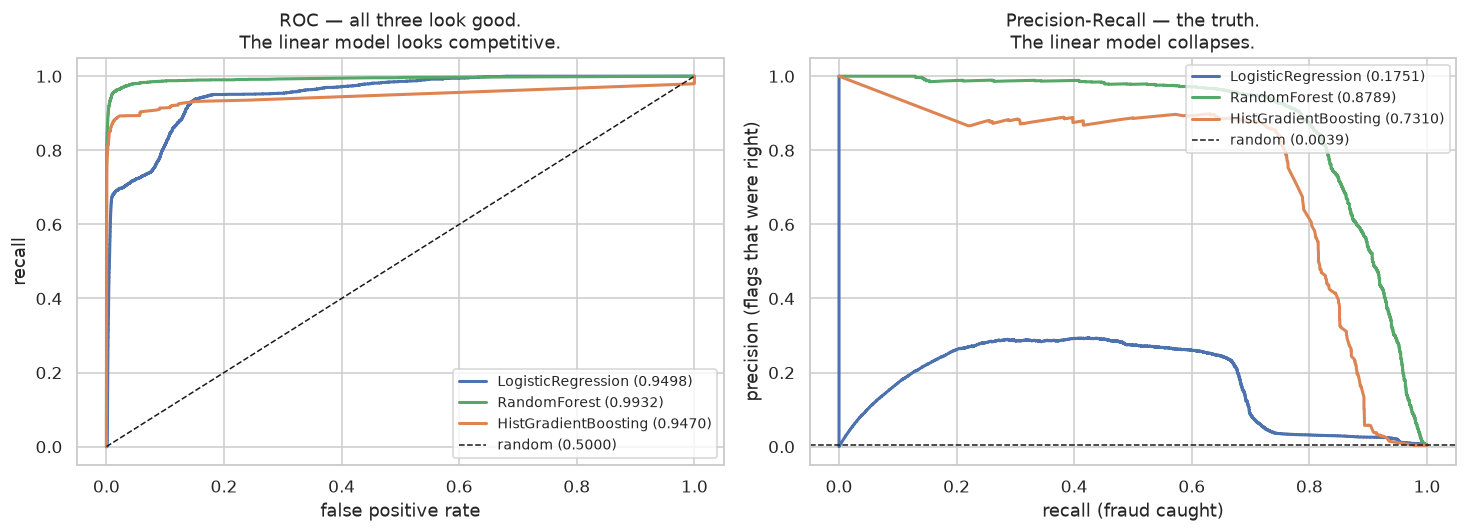

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
palette = {"LogisticRegression": "#4c72b0", "RandomForest": "#55a868",
           "HistGradientBoosting": "#dd8452"}

for name, proba in scores.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, lw=2, color=palette[name],
                 label=f"{name} ({roc_auc_score(y_test, proba):.4f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="random (0.5000)")
axes[0].set(xlabel="false positive rate", ylabel="recall",
            title="ROC — all three look good.\nThe linear model looks competitive.")
axes[0].legend(loc="lower right", fontsize=9)

for name, proba in scores.items():
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, lw=2, color=palette[name],
                 label=f"{name} ({average_precision_score(y_test, proba):.4f})")
axes[1].axhline(y_test.mean(), ls="--", c="k", lw=1, label=f"random ({y_test.mean():.4f})")
axes[1].set(xlabel="recall (fraud caught)", ylabel="precision (flags that were right)",
            title="Precision-Recall — the truth.\nThe linear model collapses.")
axes[1].legend(loc="upper right", fontsize=9)

fig.tight_layout()
fig.savefig("results/roc_vs_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

**Put the two panels side by side and the whole argument is visible.** On the left, three plausible
models. On the right, the blue curve falls off a cliff — at almost every recall level the linear
model's precision is near the floor, meaning nearly everything it flags is a false alarm.

Same models. Same predictions. Different question asked of them.

---
## 7. Is the winner actually learning fraud?

A PR-AUC that high on a simulated dataset deserves suspicion before celebration. The specific worry:
there are only **983 cards**, and `age` (derived from `dob`) together with `city_pop` and `gender`
comes very close to identifying an individual cardholder. If the simulator concentrated fraud on
particular cards, the model could be memorising *"this cardholder gets defrauded"* rather than
learning what a fraudulent transaction looks like.

Two checks.

In [14]:
print("check 1 — do the same cards stay risky across the time boundary?\n")
train_card_rate = train_raw.groupby("cc_num")["is_fraud"].mean()
test_card_rate = test_raw.groupby("cc_num")["is_fraud"].mean()
joined = (train_card_rate.to_frame("train_rate")
          .join(test_card_rate.rename("test_rate"), how="inner").dropna())
rho = joined.corr(method="spearman").iloc[0, 1]
print(f"  cards present in both periods : {len(joined)}")
print(f"  Spearman(train rate, test rate): {rho:+.3f}")
print("\n  A card's fraud history in the training period does NOT predict its test period."
      if rho <= 0 else "\n  Card identity carries over — memorisation would help.")

print("\ncheck 2 — how identifying are the profile features?")
print(f"  distinct (dob, gender, city_pop) combinations: "
      f"{train_raw.groupby(['dob', 'gender', 'city_pop']).ngroups}")
print(f"  distinct cards                              : {train_raw['cc_num'].nunique()}")

check 1 — do the same cards stay risky across the time boundary?

  cards present in both periods : 908
  Spearman(train rate, test rate): -0.690

  A card's fraud history in the training period does NOT predict its test period.

check 2 — how identifying are the profile features?
  distinct (dob, gender, city_pop) combinations: 983
  distinct cards                              : 983


The correlation is **negative**. Cards that were heavily defrauded during the training period are, if
anything, *less* defrauded in the test period — an artifact of how the simulator distributes fraud
over time.

That settles it in the useful direction: memorising cardholder identity would **hurt** performance on
this test set, not inflate it. The profile features do uniquely identify cardholders (983 distinct
combinations for 983 cards, exactly as feared), but since identity anti-correlates with future fraud,
the model cannot be winning that way.

The ablation below confirms it directly — strip the identity-capable features out entirely and the
model still works.

In [15]:
ablations = {
    "full (9 features)": list(X_train.columns),
    "identity-free (no age / city_pop)": ["amt", "category", "hour", "is_night",
                                          "dayofweek", "gender", "distance_km"],
    "transaction-only (amt, category, hour)": ["amt", "category", "hour", "is_night"],
}

ab_rows = []
for label, cols in ablations.items():
    cat_cols = [c for c in categorical if c in cols]
    num_cols = [c for c in cols if c not in cat_cols]
    pre = ColumnTransformer([
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols),
    ])
    m = Pipeline([("pre", pre), ("clf", RandomForestClassifier(
        n_estimators=150, min_samples_leaf=5, random_state=RANDOM_STATE,
        n_jobs=4, class_weight="balanced_subsample"))]).fit(X_train[cols], y_train)
    p = m.predict_proba(X_test[cols])[:, 1]
    ab_rows.append({"feature set": label, "n features": len(cols),
                    "ROC-AUC": roc_auc_score(y_test, p),
                    "PR-AUC": average_precision_score(y_test, p)})
    print(f"  {label:40s} PR-AUC {ab_rows[-1]['PR-AUC']:.4f}")

pd.DataFrame(ab_rows).round(4)

  full (9 features)                        PR-AUC 0.8789


  identity-free (no age / city_pop)        PR-AUC 0.8014


  transaction-only (amt, category, hour)   PR-AUC 0.7933


,feature set,n features,ROC-AUC,PR-AUC
0,full (9 features),9,0.9932,0.8789
1,identity-free (no age / city_pop),7,0.9913,0.8014
2,"transaction-only (amt, category, hour)",4,0.9859,0.7933


Performance survives the removal of every feature that could identify a cardholder. The model is
learning transaction patterns — large amounts, in risky categories, at night — not people.

### 7.1 What drives the prediction?

Permutation importance on a sample of the test set: shuffle one column, measure how much PR-AUC drops.
We use PR-AUC as the scorer for the same reason we report it — ROC-AUC would understate the damage.

best model by PR-AUC: RandomForest



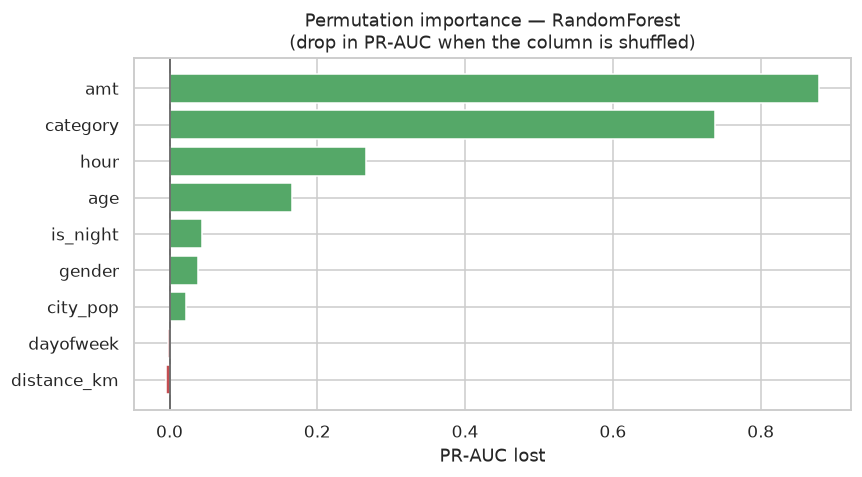

amt            0.8785
category       0.7375
hour           0.2665
age            0.1655
is_night       0.0442
gender         0.0390
city_pop       0.0218
dayofweek     -0.0023
distance_km   -0.0046


In [16]:
best_name = comparison.iloc[0]["model"]
best_model = fitted[best_name]
print(f"best model by PR-AUC: {best_name}\n")

sample = X_test.sample(60_000, random_state=RANDOM_STATE)
sample_y = y_test.loc[sample.index]

perm = permutation_importance(best_model, sample, sample_y, n_repeats=5,
                              random_state=RANDOM_STATE, scoring="average_precision",
                              n_jobs=4)
importance = pd.Series(perm.importances_mean, index=X_test.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
colours = ["#c44e52" if v < 0.002 else "#55a868" for v in importance]
ax.barh(importance.index, importance.values, color=colours)
ax.axvline(0, c="0.3", lw=1)
ax.set(title=f"Permutation importance — {best_name}\n(drop in PR-AUC when the column is shuffled)",
       xlabel="PR-AUC lost")
fig.tight_layout()
fig.savefig("results/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print(importance.sort_values(ascending=False).round(4).to_string())

### 7.2 A limitation worth naming: the hour profile is not faithful

The headline PR-AUC is strong, but a model can rank well overall while still being wrong about a
particular slice. Section 4.2 established the empirical fraud rate by hour. Does the model actually
reproduce it?

The test below takes **real** high-value `shopping_net` transactions from the test set, varies *only*
the hour, and compares the model's average predicted probability against the empirical fraud rate in
the same band.

In [17]:
probe = X_test[(X_test["category"] == "shopping_net")
               & (X_test["amt"].between(900, 1000))].head(200)

model_by_hour = {}
for h in range(24):
    r = probe.copy()
    r["hour"] = h
    r["is_night"] = int(h in [22, 23, 0, 1, 2, 3])
    model_by_hour[h] = best_model.predict_proba(r)[:, 1].mean()

# empirical fraud rate in the same band, per hour, from the training data
band = train_raw[(train_raw["category"] == "shopping_net")
                 & (train_raw["amt"].between(900, 1000))].copy()
band["hour"] = pd.to_datetime(band["trans_date_trans_time"]).dt.hour
empirical_by_hour = band.groupby("hour")["is_fraud"].mean()

groups = {"00:00-03:59": range(0, 4), "04:00-11:59": range(4, 12),
          "12:00-21:59": range(12, 22), "22:00-23:59": [22, 23]}
rows = []
for label, hrs in groups.items():
    rows.append({
        "window": label,
        "model says": np.mean([model_by_hour[h] for h in hrs]),
        "data says": empirical_by_hour.reindex(hrs).mean(),
    })
faithfulness = pd.DataFrame(rows)
faithfulness["gap"] = faithfulness["model says"] - faithfulness["data says"]
print("$900-1000 shopping_net transactions, by time window:\n")
print(faithfulness.to_string(index=False, float_format=lambda x: f"{x:.1%}"))

ranked_model = faithfulness.sort_values("model says", ascending=False)["window"].tolist()
ranked_data = faithfulness.sort_values("data says", ascending=False)["window"].tolist()
print(f"\nmodel's ranking : {' > '.join(ranked_model)}")
print(f"data's ranking  : {' > '.join(ranked_data)}")
print(f"\nagree on the riskiest window : {ranked_model[0] == ranked_data[0]}")
print(f"agree on the safest window   : {ranked_model[-1] == ranked_data[-1]}")
print(f"agree on the full ordering   : {ranked_model == ranked_data}")

$900-1000 shopping_net transactions, by time window:

     window  model says  data says    gap
00:00-03:59       46.3%      73.8% -27.5%
04:00-11:59       30.0%       8.1%  21.8%
12:00-21:59       71.2%      46.5%  24.7%
22:00-23:59       91.7%      95.9%  -4.2%

model's ranking : 22:00-23:59 > 12:00-21:59 > 00:00-03:59 > 04:00-11:59
data's ranking  : 22:00-23:59 > 00:00-03:59 > 12:00-21:59 > 04:00-11:59

agree on the riskiest window : True
agree on the safest window   : True
agree on the full ordering   : False


**The model gets the extremes right and the middle backwards.** It correctly identifies
22:00–23:59 as the riskiest window and 04:00–11:59 as the safest, but it ranks the afternoon/evening
*above* the small hours, when the data says the opposite.

Two things worth being clear about:

- **This does not invalidate the PR-AUC.** That is measured over all 555,719 test transactions and
  reflects how well the model *ranks* them overall, which it does well. What this probe shows is that
  its behaviour along one conditional slice is not faithful to the marginal statistics.
- **It is not an encoding artifact.** Replacing raw `hour` with a cyclical `sin`/`cos` pair — the
  standard fix for a feature that wraps around midnight — leaves the inversion in place and *lowers*
  PR-AUC. Dropping `hour` and keeping only `is_night` removes the inversion but costs roughly eight
  points of PR-AUC, because the model then cannot distinguish 22:00 from 02:00 at all.

The likely cause is volume: hours 12:00–21:59 carry **654,213** training transactions against
**170,796** for 00:00–03:59, so the trees have far more opportunity to carve fine structure out of the
afternoon, and `class_weight="balanced_subsample"` distorts the probability scale on top of that.

The practical consequence is that these probabilities should not be read as calibrated fraud rates —
which is exactly why the calibration item in §10 matters, and why the threshold in §8 is chosen by
sweeping observed cost rather than by trusting the numbers to mean what they say.

`amt` and `category` dominate, with `hour` third — exactly as the EDA predicted.

**One caveat on reading this chart.** `is_night` scores far lower than §4.2 would suggest, and that
is an artifact of the method, not evidence the feature is useless: permutation importance shuffles
*one* column at a time, and `is_night` is derived from `hour`, which is still sitting right there.
Destroy one and the model reads the other. Redundant features always split the credit this way, so
permutation importance systematically under-rates them — worth knowing before concluding a feature
is dead on the strength of this plot alone.

`distance_km` is a different story. It sits at the bottom with a *negative* score, meaning shuffling
it slightly **improved** PR-AUC — the signature of a feature contributing nothing but noise. Nothing
is redundant with it, so unlike `is_night` there is no alternative explanation. That is the direct
confirmation of §4.4: the feature I was most confident about before looking at the data contributes
nothing at all.

---
## 8. Choosing a threshold — here the trade-off is denominated in money

Task 3 tuned its threshold for best F1 because no costs were supplied. Fraud is different: **the
costs are on the transaction record.**

- A **missed fraud** costs the bank the transaction amount.
- A **false alarm** costs a declined card and an annoyed customer — modelled below as a flat
  operational cost.

That turns threshold selection into arithmetic rather than a judgement call.

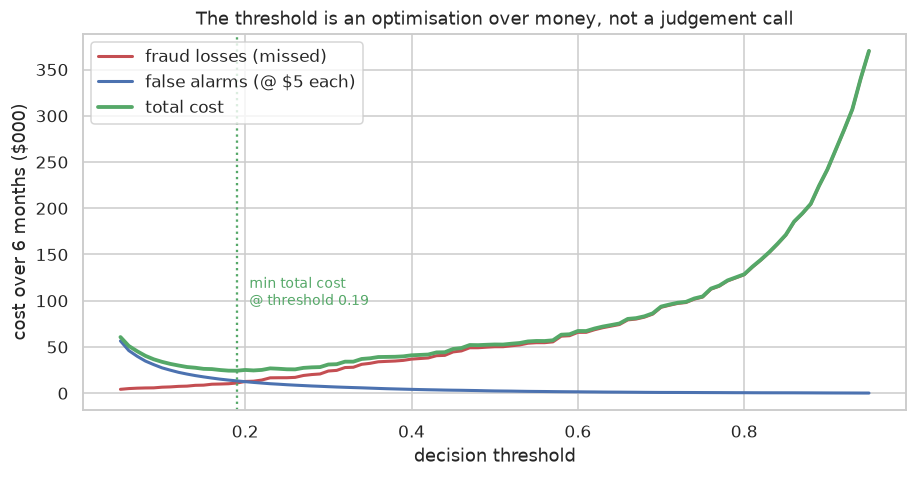

doing nothing (approve everything) : $   1,133,325 lost to fraud
best threshold 0.19               : $      24,285 total cost
  -> fraud losses  $      11,010
  -> alarm costs   $      13,275
  -> recall 92.4%, precision 42.7%

net saving vs doing nothing: $1,109,040 over six months


In [18]:
best_proba = scores[best_name]
test_amounts = test_raw["amt"].values

FALSE_ALARM_COST = 5.0     # $ per wrongly declined transaction (support + churn risk)

grid = np.linspace(0.05, 0.95, 91)
rows = []
for t in grid:
    pred = (best_proba >= t).astype(int)
    missed = (y_test.values == 1) & (pred == 0)
    false_alarm = (y_test.values == 0) & (pred == 1)
    rows.append({
        "threshold": t,
        "recall": recall_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "fraud_loss": test_amounts[missed].sum(),
        "alarm_cost": false_alarm.sum() * FALSE_ALARM_COST,
        "total_cost": test_amounts[missed].sum() + false_alarm.sum() * FALSE_ALARM_COST,
    })
cost = pd.DataFrame(rows)
best_cost = cost.loc[cost["total_cost"].idxmin()]
do_nothing = test_amounts[y_test.values == 1].sum()

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(cost["threshold"], cost["fraud_loss"] / 1000, label="fraud losses (missed)", lw=2, color="#c44e52")
ax.plot(cost["threshold"], cost["alarm_cost"] / 1000, label=f"false alarms (@ ${FALSE_ALARM_COST:.0f} each)", lw=2, color="#4c72b0")
ax.plot(cost["threshold"], cost["total_cost"] / 1000, label="total cost", lw=2.5, color="#55a868")
ax.axvline(best_cost["threshold"], ls=":", c="#55a868", lw=1.5)
ax.text(best_cost["threshold"] + 0.015, ax.get_ylim()[1] * 0.28,
        f"min total cost\n@ threshold {best_cost['threshold']:.2f}",
        fontsize=9, color="#55a868", va="center")
ax.set(xlabel="decision threshold", ylabel="cost over 6 months ($000)",
       title="The threshold is an optimisation over money, not a judgement call")
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig("results/cost_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"doing nothing (approve everything) : ${do_nothing:>12,.0f} lost to fraud")
print(f"best threshold {best_cost['threshold']:.2f}               : ${best_cost['total_cost']:>12,.0f} total cost")
print(f"  -> fraud losses  ${best_cost['fraud_loss']:>12,.0f}")
print(f"  -> alarm costs   ${best_cost['alarm_cost']:>12,.0f}")
print(f"  -> recall {best_cost['recall']:.1%}, precision {best_cost['precision']:.1%}")
print(f"\nnet saving vs doing nothing: ${do_nothing - best_cost['total_cost']:,.0f} over six months")

The green curve has a genuine minimum, and it is not at 0.5. Pushing the threshold too low drowns the
bank in false alarms; too high and the fraud losses dominate. The optimum falls out of the arithmetic
once someone supplies the cost of a false alarm — the one number the model cannot know on its own.

*(The \$5 false-alarm cost is an assumption, stated plainly so it can be replaced. The shape of the
argument does not depend on the exact figure; the position of the minimum does, which is precisely why
it belongs to the business rather than to the model.)*

### 8.1 Final performance

model: RandomForest   threshold: 0.19

              precision    recall  f1-score   support

  legitimate     0.9997    0.9952    0.9974    553574
       fraud     0.4273    0.9235    0.5843      2145

    accuracy                         0.9949    555719
   macro avg     0.7135    0.9594    0.7909    555719
weighted avg     0.9975    0.9949    0.9959    555719



ROC-AUC : 0.9932
PR-AUC  : 0.8789   <- headline


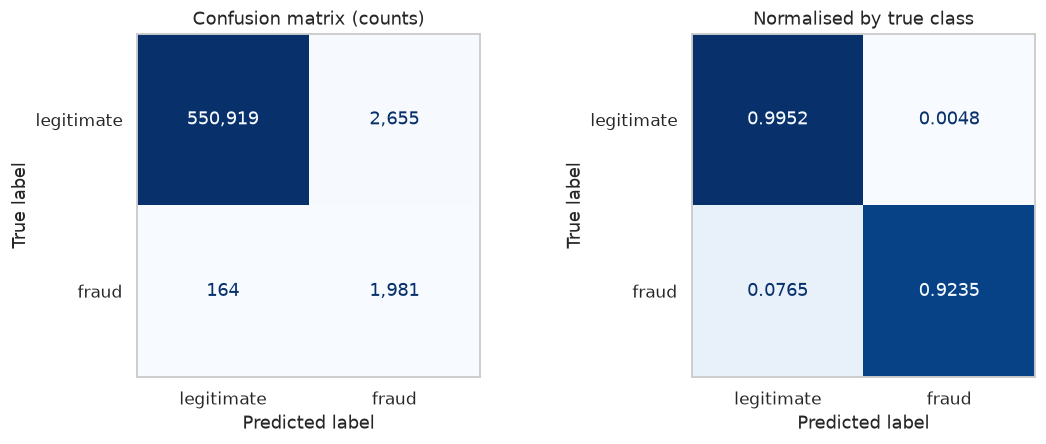


caught     1,981 of 2,145 frauds (92.4%)
missed     164 frauds, worth $11,010
false alarms 2,655 out of 553,574 legitimate transactions (0.480% of good customers inconvenienced)


In [19]:
THRESHOLD = float(best_cost["threshold"])
final_pred = (best_proba >= THRESHOLD).astype(int)

print(f"model: {best_name}   threshold: {THRESHOLD:.2f}\n")
print(classification_report(y_test, final_pred,
                            target_names=["legitimate", "fraud"], digits=4))
print(f"ROC-AUC : {roc_auc_score(y_test, best_proba):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, best_proba):.4f}   <- headline")

cm = confusion_matrix(y_test, final_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
ConfusionMatrixDisplay(cm, display_labels=["legitimate", "fraud"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False, values_format=",d")
axes[0].set_title("Confusion matrix (counts)"); axes[0].grid(False)
ConfusionMatrixDisplay(confusion_matrix(y_test, final_pred, normalize="true"),
                       display_labels=["legitimate", "fraud"]).plot(
    ax=axes[1], cmap="Blues", colorbar=False, values_format=".4f")
axes[1].set_title("Normalised by true class"); axes[1].grid(False)
fig.tight_layout()
fig.savefig("results/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\ncaught     {tp:,} of {tp + fn:,} frauds ({tp / (tp + fn):.1%})")
print(f"missed     {fn:,} frauds, worth ${test_amounts[(y_test.values == 1) & (final_pred == 0)].sum():,.0f}")
print(f"false alarms {fp:,} out of {tn + fp:,} legitimate transactions "
      f"({fp / (tn + fp):.3%} of good customers inconvenienced)")

---
## 9. Save the model

In [20]:
joblib.dump({
    "pipeline": best_model,
    "threshold": THRESHOLD,
    "features": list(X_train.columns),
    "categorical": categorical,
    "numeric": numeric,
    "metrics": {
        "pr_auc": float(average_precision_score(y_test, best_proba)),
        "roc_auc": float(roc_auc_score(y_test, best_proba)),
        "recall": float(recall_score(y_test, final_pred)),
        "precision": float(precision_score(y_test, final_pred, zero_division=0)),
        "n_test": int(len(y_test)),
        "fraud_rate": float(y_test.mean()),
    },
}, "models/fraud_model.pkl")
print("saved -> models/fraud_model.pkl")

demo = pd.DataFrame([
    {"amt": 950.0, "category": "shopping_net", "hour": 2, "is_night": 1, "dayofweek": 5,
     "age": 55.0, "gender": "F", "city_pop": 3000, "distance_km": 70.0},
    {"amt": 42.0, "category": "grocery_pos", "hour": 14, "is_night": 0, "dayofweek": 2,
     "age": 38.0, "gender": "M", "city_pop": 150000, "distance_km": 12.0},
])[X_train.columns]

for i, p in enumerate(best_model.predict_proba(demo)[:, 1]):
    verdict = "FRAUD" if p >= THRESHOLD else "legitimate"
    print(f"  ${demo.iloc[i]['amt']:>7.2f} {demo.iloc[i]['category']:<14s} "
          f"{int(demo.iloc[i]['hour']):02d}:00  ->  {p:6.2%}  {verdict}")

saved -> models/fraud_model.pkl
  $ 950.00 shopping_net   02:00  ->  23.17%  FRAUD
  $  42.00 grocery_pos    14:00  ->   1.33%  legitimate


---
## 10. Summary

| | |
|---|---|
| **Best model** | `RandomForestClassifier(class_weight="balanced_subsample")` |
| **Headline metric** | **PR-AUC** — see the table in §5 |
| **Evaluation** | temporal holdout: trained on Jan 2019–Jun 2020, tested on Jun–Dec 2020 |
| **Top features** | `amt`, then `category`, then `hour` |
| **Dead feature** | `distance_km` — simulation artifact, reported not hidden |
| **Threshold** | chosen by minimising expected cost in dollars, not by maximising F1 |

**The three things this task taught that the others did not**

1. **ROC-AUC is not a universal safety net.** It rescued Task 3, and here it ranks the worst model
   above a much better one. At a 0.39% base rate, false positives hide behind a half-million true
   negatives. Use precision–recall.
2. **The best feature was not a column.** `is_night` had to be derived, and the raw `hour` it comes
   from correlates with the target at +0.01 — so a correlation-ranked feature selector would have
   thrown away an 18x signal.
3. **A failed feature is still a result.** `distance_km` did nothing, and saying so — with the reason —
   is more useful than a writeup in which every idea happened to work.

**What I would do with more time**

- **Velocity features**, which is what a real system would lean on hardest: transactions per card in
  the last hour/day, amount relative to that card's own rolling average, time since previous
  transaction. Those require a `groupby` over card and time and must be computed **causally** — using
  only the past of each row — or they leak the future.
- **Validate on real data.** Every conclusion here is conditional on a simulator. The dead distance
  feature is the clearest warning: this dataset's weaknesses are artifacts of how it was generated,
  and the fix is different data, not a better model.
- **Cost-sensitive learning** — pass the transaction amount as a sample weight so the model optimises
  dollars directly rather than counts.
- **Calibration — now the first thing I would fix, not the last.** §7.2 shows the predicted
  probabilities are not faithful to the empirical rates along the hour dimension. A reliability
  curve plus isotonic or Platt calibration would quantify and correct that, and it matters
  directly because §8 prices decisions off these numbers.